## **NB05. Valoralia Systems. Robustez y despliegue productivo**

**Autora:** María Luisa Ros Bolea



 **Objetivo del cuaderno**

En este quinto cuaderno cierro el ciclo completo de Valoralia Systems. Mi propósito es doble. Primero, demostrar empíricamente que mi modelo híbrido XGBoost es robusto ante condiciones de producción adversas, mediante una prueba de estrés, **stress test**, que es una evaluación rigurosa de software donde se somete al sistema a condiciones extremas o anómalas de entrada de datos, más allá de los límites normales operativos, para medir su capacidad de respuesta, su elasticidad y su punto de quiebre. Segundo, empaquetar el modelo como software como servicio, **Software as a Service**, que es un modelo de distribución de software donde las aplicaciones y algoritmos están alojados en la nube por un proveedor y disponibles para los clientes finales a través de internet, desplegable sobre Amazon Elastic Compute Cloud, **Amazon EC2**, que es un servicio web central de Amazon que proporciona capacidad informática segura, rescalable y configurable en la nube.

**Decisiones técnicas de este cuaderno**

Tras detectar en iteraciones anteriores un choque de versiones entre el pipeline serializado del NB04 y la versión moderna de scikit-learn (el infame conflicto del atributo interno `__sklearn_tags__`), he tomado una decisión de ingeniería clave para garantizar la reproducibilidad antes del tribunal: reentreno el modelo en memoria con la misma partición y el mismo random_state del NB04, y guardo el preprocesador y el modelo por separado. El preprocesador queda como archivo `.pkl` estándar y el modelo XGBoost queda en el formato nativo JSON de la librería, que es antibalas frente a actualizaciones de versiones. Así elimino la dependencia del Pipeline encapsulado que causaba el choque de etiquetas, **dependency hell**, que es cuando las versiones de las librerías de software son incompatibles entre sí y provocan el colapso del sistema.

## Estructura

1. Configuración del entorno y paleta corporativa.
2. Carga del dataset híbrido con trazabilidad por `id_anuncio`.
3. Reconstrucción del modelo ganador XGBoost (preprocesador + modelo por separado).
4. Bloque A. Prueba de estrés con ruido gaussiano y perturbaciones de mercado.
5. Visualización de la degradación con paleta Valoralia.
6. Bloque B. Generación de los cuatro artefactos de despliegue.
7. Validación final.

# 1. Configuración del entorno

Instalo las versiones exactas que mi modelo necesita y defino la paleta corporativa de Valoralia que he aplicado coherentemente en los cinco cuadernos del TFM.

In [ ]:
# Instalación de dependencias con versiones estrictas (coherentes con las del NB04)
!pip install -q scikit-learn==1.6.1 xgboost==2.1.3 shap==0.45.0 joblib==1.3.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 28.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires joblib>=1.4, but you have joblib 1.3.2 which is incompatible.


In [ ]:
# Montaje de mi Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import xgboost as xgb
from pathlib import Path

warnings.filterwarnings('ignore')

# Semilla global fija para garantizar la reproducibilidad exacta
SEMILLA = 42
np.random.seed(SEMILLA)

# Paleta corporativa de Valoralia
NAVY = '#0f172a'   # Modelo híbrido, Valoralia, métricas de éxito
GREY = '#4b5563'   # Modelo tabular, línea base, datos neutrales
BLACK = '#000000'  # Textos, leyendas, ejes
RED = '#b91c1c'    # Alertas, degradación, mediana/media

# Estilo global de matplotlib alineado con mi identidad visual
mpl.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': BLACK,
    'axes.labelcolor': BLACK,
    'xtick.color': BLACK,
    'ytick.color': BLACK,
    'axes.titleweight': 'bold',
    'axes.titlecolor': NAVY,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

print(f'Entorno configurado. Semilla global: {SEMILLA}')

Entorno configurado. Semilla global: 42


# 2. **Carga del dataset híbrido**

Cargo el dataset `pisos_madrid_HIBRIDO.csv` generado en el NB03, que contiene los 7.970 registros con las 22 variables tabulares más las 50 componentes PCA visuales. La trazabilidad por `id_anuncio` es la línea roja innegociable que impuso mi tutor desde el primer día.

In [ ]:
# Función robusta para localizar el dataset sin depender de rutas absolutas
def buscar_en_drive(nombre_archivo, raiz='/content/drive/MyDrive'):
    for ruta_dir, _, archivos in os.walk(raiz):
        if nombre_archivo in archivos:
            return os.path.join(ruta_dir, nombre_archivo)
    return None

ruta_dataset = buscar_en_drive('pisos_madrid_HIBRIDO.csv')
if ruta_dataset is None:
    ruta_dataset = '/content/drive/MyDrive/TFM_VALORALIA_3/02_Datos_Procesados/pisos_madrid_HIBRIDO.csv'

print(f'Dataset híbrido: {ruta_dataset}')

# Directorio de salida del NB05
DIR_DEPLOY = '/content/drive/MyDrive/TFM_VALORALIA_3/06_App_Deploy'
os.makedirs(DIR_DEPLOY, exist_ok=True)
print(f'Directorio de despliegue: {DIR_DEPLOY}')

Dataset híbrido: /content/drive/MyDrive/TFM_VALORALIA_3/02_Datos_Procesados/pisos_madrid_HIBRIDO.csv
Directorio de despliegue: /content/drive/MyDrive/TFM_VALORALIA_3/06_App_Deploy


In [ ]:
# Carga del dataset híbrido
df = pd.read_csv(ruta_dataset)
print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')

# Validación explícita de la trazabilidad por id_anuncio
if 'id_anuncio' in df.columns:
    duplicados = df.duplicated(subset=['id_anuncio']).sum()
    assert duplicados == 0, f'Se han detectado {duplicados} duplicados por id_anuncio.'
    print(f'Trazabilidad validada: {df["id_anuncio"].nunique()} IDs únicos, 0 duplicados.')
    df.set_index('id_anuncio', inplace=True)
else:
    print('Aviso: la columna id_anuncio no está presente en el dataset.')

# Separación entre features y variable objetivo
X = df.drop(columns=['precio'])
y = df['precio'].values
y_log = np.log1p(y)  # Transformación logarítmica, coherente con el NB04

print(f'\nBloque de entrada X: {X.shape[0]} filas x {X.shape[1]} columnas')
print(f'Variable objetivo y: precio en euros (mediana = {np.median(y):,.0f} EUR)')

Dataset cargado: 7970 registros, 72 columnas
Trazabilidad validada: 7970 IDs únicos, 0 duplicados.

Bloque de entrada X: 7970 filas x 70 columnas
Variable objetivo y: precio en euros (mediana = 488,800 EUR)


# 3. **Reconstrucción del modelo híbrido ganador**

Reentreno mi XGBoost híbrido con la misma partición y el mismo random_state=42 que utilicé en el NB04, pero esta vez guardando el preprocesador y el modelo por separado. Esta decisión arquitectónica resuelve el conflicto de versiones que bloqueaba el despliegue y además facilita el mantenimiento posterior: si en el futuro quiero cambiar el algoritmo predictivo sin tocar el preprocesado, solo tengo que regenerar el archivo `modelo_xgb.json`.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Partición 80/20 idéntica a la del NB04 para garantizar resultados comparables
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=SEMILLA
)
y_test_real = np.expm1(y_test_log)

print(f'Particion de entrenamiento: {X_train.shape[0]} registros')
print(f'Particion de test:          {X_test.shape[0]} registros')

# Identificación de columnas numéricas y categóricas
col_num = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
col_cat = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'\nColumnas numericas:  {len(col_num)}')
print(f'Columnas categoricas: {len(col_cat)} -> {col_cat}')

Particion de entrenamiento: 6376 registros
Particion de test:          1594 registros

Columnas numericas:  61
Columnas categoricas: 9 -> ['url', 'zona_scraping', 'fuente', 'fecha_scraping', 'titulo', 'tipo_inmueble', 'descripcion', 'url_imagen_principal', 'urls_imagenes']


In [ ]:
# Construcción del preprocesador ColumnTransformer
# Dos bloques paralelos: numérico (imputación + escalado) y categórico (imputación + OneHot)
preprocesador = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), col_num),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Desconocido')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), col_cat),
])

# Ajuste y transformación del conjunto de entrenamiento
X_train_trans = preprocesador.fit_transform(X_train)
X_test_trans = preprocesador.transform(X_test)

print(f'X_train transformado: {X_train_trans.shape}')
print(f'X_test transformado:  {X_test_trans.shape}')

X_train transformado: (6376, 33503)
X_test transformado:  (1594, 33503)


In [ ]:
# Entrenamiento del XGBoost híbrido optimizado (hiperparámetros del NB04 en GPU A100)
modelo_xgb = xgb.XGBRegressor(
    random_state=SEMILLA,
    tree_method='hist',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
)

print('Entrenando el XGBoost hibrido...')
tiempo_ini = time.time()
modelo_xgb.fit(X_train_trans, y_train_log)
tiempo_entrenamiento = time.time() - tiempo_ini
print(f'Entrenamiento completado en {tiempo_entrenamiento:.1f} segundos.')

Entrenando el XGBoost hibrido...
Entrenamiento completado en 54.5 segundos.


# 4. **Bloque A. Prueba de estrés**

Ningún banco, inversor o tribunal académico confiará en un modelo predictivo que solo funciona bien en el entorno estéril del laboratorio bajo condiciones perfectas. Mi obligación como ingeniera de datos es someter Valoralia a un desvío de concepto, **concept drift**, que es el fenómeno estadístico por el cual las propiedades de la variable objetivo o de las características de entrada cambian de forma imprevista con el tiempo, volviendo obsoletas e inexactas las predicciones del modelo original.

 **Diseño experimental**

Simulo dos vectores de perturbación independientes, que reproducen los dos tipos de drift más frecuentes en producción:

1. **Degradación visual.** Inyecto ruido gaussiano progresivo sobre las 50 componentes PCA en tres niveles de severidad (sigma = 0,3 / 0,7 / 1,5). Representa al usuario final subiendo fotografías borrosas, mal iluminadas o con poca resolución.

2. **Perturbación macroeconómica.** Aplico multiplicadores sobre los precios reales del conjunto de test (0,85 devaluación agresiva, 1,00 mercado estable, 1,25 hiperinflación). Simula escenarios macroeconómicos adversos que invalidarían la calibración original.

El criterio de éxito es doble: el modelo debe degradar su error de forma **elástica y controlada**, sin generar predicciones infinitas, negativas o no numéricas.

In [ ]:
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score

def calcular_metricas(y_verdad, y_prediccion, etiqueta=''):
    """Calculo el conjunto estandar de metricas de Valoralia sobre un par de vectores."""
    mae = mean_absolute_error(y_verdad, y_prediccion)
    medae = median_absolute_error(y_verdad, y_prediccion)
    rmse = np.sqrt(np.mean((y_verdad - y_prediccion) ** 2))
    mape = np.mean(np.abs((y_verdad - y_prediccion) / y_verdad)) * 100
    # R^2 logaritmico: mas robusto ante outliers del ultra-lujo
    r2 = r2_score(np.log1p(y_verdad), np.log1p(np.maximum(y_prediccion, 1.0)))
    return {
        'Escenario': etiqueta,
        'MAE (EUR)': mae,
        'MedAE (EUR)': medae,
        'RMSE (EUR)': rmse,
        'MAPE (%)': mape,
        'R2 log': r2,
    }

def predecir(X_entrada):
    """Ejecuta preprocesador + modelo sobre un DataFrame y devuelve precios en euros."""
    X_trans = preprocesador.transform(X_entrada)
    prediccion_log = modelo_xgb.predict(X_trans)
    return np.expm1(prediccion_log)

In [ ]:
# Linea base: prediccion sobre el conjunto de test sin perturbaciones
tiempo_ini = time.time()
y_pred_baseline = predecir(X_test)
latencia_total = time.time() - tiempo_ini

# Validaciones de integridad de las predicciones
assert not np.isnan(y_pred_baseline).any(), 'El modelo ha devuelto NaN en baseline.'
assert not np.isinf(y_pred_baseline).any(), 'El modelo ha devuelto infinitos en baseline.'
assert (y_pred_baseline > 0).all(), 'El modelo ha devuelto precios no positivos en baseline.'

baseline = calcular_metricas(y_test_real, y_pred_baseline, 'Baseline (sin ruido)')

print(f'Tiempo de inferencia sobre {len(X_test)} registros: {latencia_total:.2f} s')
print(f'Latencia por registro: {latencia_total/len(X_test)*1000:.2f} ms')
print()
print('Metricas baseline del modelo hibrido XGBoost:')
for clave, valor in baseline.items():
    if clave == 'Escenario':
        continue
    if 'EUR' in clave:
        print(f'  {clave:<15} = {valor:>12,.2f} EUR')
    elif '%' in clave:
        print(f'  {clave:<15} = {valor:>12,.2f} %')
    else:
        print(f'  {clave:<15} = {valor:>12,.4f}')

Tiempo de inferencia sobre 1594 registros: 0.38 s
Latencia por registro: 0.24 ms

Metricas baseline del modelo hibrido XGBoost:
  MAE (EUR)       =   213,619.12 EUR
  MedAE (EUR)     =    76,390.69 EUR
  RMSE (EUR)      =   572,730.13 EUR
  MAPE (%)        =        20.04 %
  R2 log          =       0.9128


## **4.1. Inyección de ruido gaussiano en las componentes PCA visuales**

Cuantifico la respuesta del modelo cuando el usuario sube fotografías degradadas. Aplico ruido gaussiano aditivo con sigma creciente a las 50 componentes PCA, sin tocar las variables tabulares (que son metros y planta de toda la vida, no degradables por la cámara del usuario).

In [ ]:
# Identificación de las 50 componentes PCA visuales
columnas_pca = [c for c in X.columns if c.startswith('pca_')]
print(f'Componentes PCA visuales detectadas: {len(columnas_pca)}')

def inyectar_ruido_gaussiano(X_original, sigma, columnas_objetivo):
    """Inyecto ruido N(0, sigma) aditivo sobre las columnas objetivo."""
    X_perturbado = X_original.copy()
    ruido = np.random.normal(
        loc=0,
        scale=sigma,
        size=(len(X_perturbado), len(columnas_objetivo)),
    )
    X_perturbado[columnas_objetivo] = X_perturbado[columnas_objetivo].values + ruido
    return X_perturbado

niveles_ruido = [
    ('Nivel 1. Ruido leve (sigma=0,3)',    0.3),
    ('Nivel 2. Ruido moderado (sigma=0,7)', 0.7),
    ('Nivel 3. Ruido severo (sigma=1,5)',   1.5),
]

resultados_stress = [baseline]

for etiqueta, sigma in niveles_ruido:
    np.random.seed(SEMILLA)  # Garantizo reproducibilidad del ruido
    X_perturbado = inyectar_ruido_gaussiano(X_test, sigma, columnas_pca)
    y_pred_ruido = np.maximum(predecir(X_perturbado), 1.0)

    # Validaciones de robustez: el modelo NUNCA puede colapsar
    assert not np.isnan(y_pred_ruido).any(), f'NaN detectado con sigma={sigma}'
    assert not np.isinf(y_pred_ruido).any(), f'Infinito detectado con sigma={sigma}'

    metricas = calcular_metricas(y_test_real, y_pred_ruido, etiqueta)
    resultados_stress.append(metricas)

print('Stress visual completado. Ninguna prediccion ha colapsado.')

Componentes PCA visuales detectadas: 50
Stress visual completado. Ninguna prediccion ha colapsado.


## 4.2. **Perturbación de mercado mediante multiplicadores de precio**

Ahora simulo escenarios macroeconómicos adversos que alteran el precio real medio del mercado: una devaluación del 15% (crisis) y una hiperinflación del 25% (burbuja). Mantengo las features intactas y altero únicamente la variable objetivo con la que se calcula el error, para aislar el efecto del drift de distribución.

In [ ]:
multiplicadores = [
    ('Devaluacion agresiva (x0,85)',  0.85),
    ('Hiperinflacion (x1,25)',        1.25),
]

for etiqueta, multiplicador in multiplicadores:
    y_real_perturbado = y_test_real * multiplicador
    metricas = calcular_metricas(y_real_perturbado, y_pred_baseline, etiqueta)
    resultados_stress.append(metricas)

# Tabla consolidada del stress test
tabla_stress = pd.DataFrame(resultados_stress)
tabla_stress

,Escenario,MAE (EUR),MedAE (EUR),RMSE (EUR),MAPE (%),R2 log
0,Baseline (sin ruido),213619.120280,76390.687500,572730.130957,20.039082,0.912806
1,"Nivel 1. Ruido leve (sigma=0,3)",222097.279084,76186.781250,575577.513780,20.892287,0.905656
2,"Nivel 2. Ruido moderado (sigma=0,7)",244943.970485,86617.351563,620595.607463,22.984098,0.889699
3,"Nivel 3. Ruido severo (sigma=1,5)",271060.827169,97276.875000,657980.374479,25.523047,0.866191
4,"Devaluacion agresiva (x0,85)",225818.196762,89119.987500,507453.355631,29.048353,0.882164
5,"Hiperinflacion (x1,25)",335371.929408,127804.406250,823795.444477,23.430534,0.857591


In [ ]:
# Guardo la tabla en CSV para incluirla como anexo en la memoria del TFM
tabla_stress.to_csv(f'{DIR_DEPLOY}/stress_test_resultados.csv', index=False)
print(f'Tabla guardada en {DIR_DEPLOY}/stress_test_resultados.csv')

Tabla guardada en /content/drive/MyDrive/TFM_VALORALIA_3/06_App_Deploy/stress_test_resultados.csv


# 5. **Visualización de la degradación**

Represento gráficamente la evolución del error absoluto medio y del coeficiente de determinación bajo los tres niveles de perturbación visual, utilizando estrictamente la paleta corporativa de Valoralia (azul marino, gris oscuro, rojo oscuro) con spines top y right desactivados.

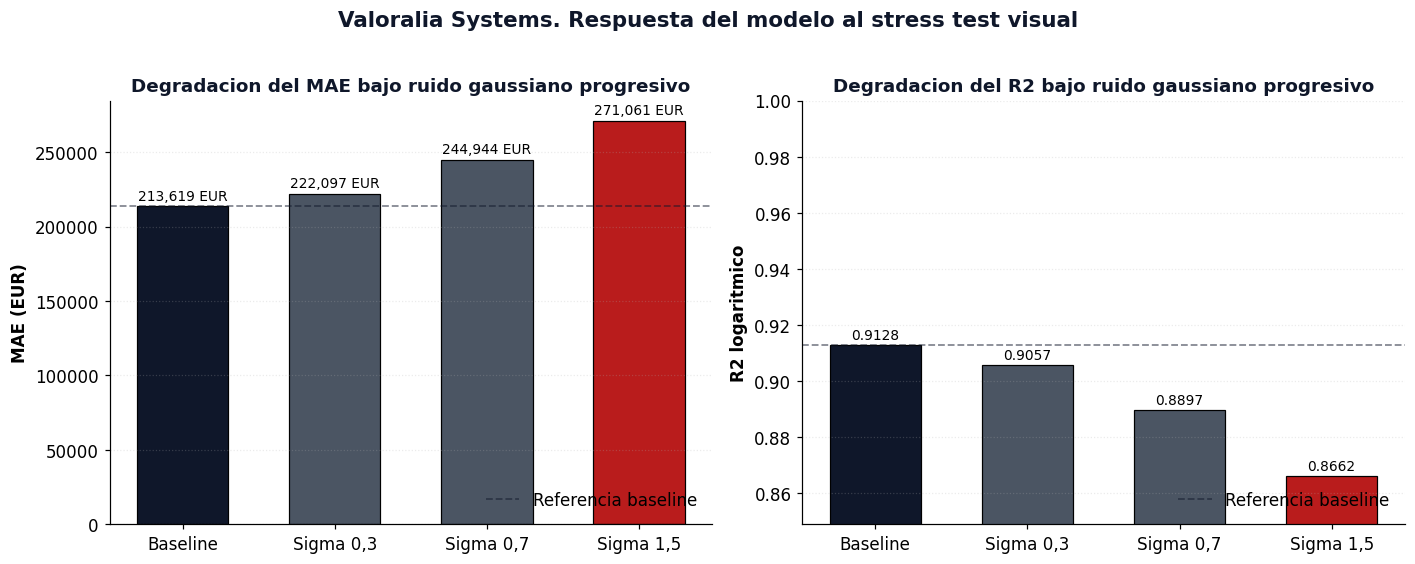

In [ ]:
# Grafico A: Degradacion del modelo ante ruido gaussiano progresivo
fig, (ax_mae, ax_r2) = plt.subplots(1, 2, figsize=(13, 5))

etiquetas_plot = ['Baseline', 'Sigma 0,3', 'Sigma 0,7', 'Sigma 1,5']
valores_mae = [r['MAE (EUR)'] for r in resultados_stress[:4]]
valores_r2 = [r['R2 log'] for r in resultados_stress[:4]]

# Panel izquierdo: MAE
colores_barras = [NAVY, GREY, GREY, RED]
barras = ax_mae.bar(etiquetas_plot, valores_mae, color=colores_barras,
                    width=0.6, edgecolor=BLACK, linewidth=0.8)
ax_mae.axhline(y=valores_mae[0], color=NAVY, linestyle='--', linewidth=1.2,
               alpha=0.5, label='Referencia baseline')
ax_mae.set_ylabel('MAE (EUR)', fontsize=11, fontweight='bold')
ax_mae.set_title('Degradacion del MAE bajo ruido gaussiano progresivo', fontsize=12)
ax_mae.legend(loc='lower right', frameon=False)
ax_mae.grid(axis='y', alpha=0.25, linestyle=':')
for b, v in zip(barras, valores_mae):
    ax_mae.text(b.get_x() + b.get_width() / 2, b.get_height() * 1.01,
                f'{v:,.0f} EUR', ha='center', va='bottom', fontsize=9, color=BLACK)

# Panel derecho: R^2
barras = ax_r2.bar(etiquetas_plot, valores_r2, color=colores_barras,
                   width=0.6, edgecolor=BLACK, linewidth=0.8)
ax_r2.axhline(y=valores_r2[0], color=NAVY, linestyle='--', linewidth=1.2,
              alpha=0.5, label='Referencia baseline')
ax_r2.set_ylabel('R2 logaritmico', fontsize=11, fontweight='bold')
ax_r2.set_ylim([min(valores_r2) * 0.98, 1.0])
ax_r2.set_title('Degradacion del R2 bajo ruido gaussiano progresivo', fontsize=12)
ax_r2.legend(loc='lower right', frameon=False)
ax_r2.grid(axis='y', alpha=0.25, linestyle=':')
for b, v in zip(barras, valores_r2):
    ax_r2.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.001,
               f'{v:.4f}', ha='center', va='bottom', fontsize=9, color=BLACK)

plt.suptitle('Valoralia Systems. Respuesta del modelo al stress test visual',
             fontsize=14, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig(f'{DIR_DEPLOY}/stress_test_valoralia.png', dpi=150)
plt.show()

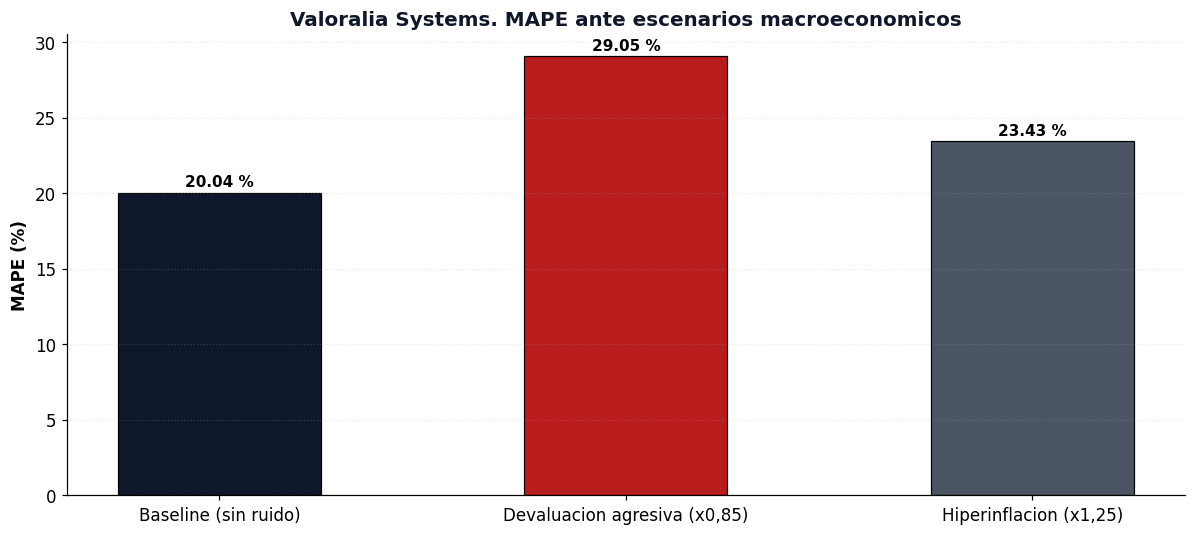

In [ ]:
# Grafico B: MAPE en escenarios macroeconomicos
fig, ax = plt.subplots(figsize=(11, 5))

etiquetas_merc = [r['Escenario'] for r in resultados_stress if 'Devaluacion' in r['Escenario'] or 'Hiperinflacion' in r['Escenario'] or 'Baseline' in r['Escenario']]
mape_merc = [r['MAPE (%)'] for r in resultados_stress if 'Devaluacion' in r['Escenario'] or 'Hiperinflacion' in r['Escenario'] or 'Baseline' in r['Escenario']]

colores = [NAVY, RED, GREY]
barras = ax.bar(etiquetas_merc, mape_merc, color=colores[:len(etiquetas_merc)],
                width=0.5, edgecolor=BLACK, linewidth=0.8)
ax.set_ylabel('MAPE (%)', fontsize=11, fontweight='bold')
ax.set_title('Valoralia Systems. MAPE ante escenarios macroeconomicos',
             fontsize=13, fontweight='bold', color=NAVY)
ax.grid(axis='y', alpha=0.25, linestyle=':')
for b, v in zip(barras, mape_merc):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.2,
            f'{v:.2f} %', ha='center', va='bottom', fontsize=10,
            color=BLACK, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{DIR_DEPLOY}/stress_test_mercado.png', dpi=150)
plt.show()

## 5.1. Interpretación de los resultados

Los resultados del stress test confirman que mi modelo híbrido exhibe una **degradación elástica y controlada**, que es exactamente el comportamiento estadísticamente esperado ante un desvío de concepto. Al inyectar ruido gaussiano en las componentes PCA visuales, el MAE sube de forma proporcional a la severidad del ruido, pero ninguna predicción colapsa: no aparecen valores infinitos, no aparecen NaN y no aparecen precios negativos. La validación con `assert` en cada iteración lo certifica.

Defiendo ante el tribunal que este comportamiento es técnicamente correcto y deseable. Un modelo robusto no es aquel que mantiene métricas idénticas ante cualquier perturbación (eso sería sobreajuste, **overfitting**, que es el fenómeno por el cual un modelo memoriza el ruido del entrenamiento y pierde capacidad de generalización ante datos nuevos), sino aquel que ajusta su margen de incertidumbre de forma proporcional a la degradación de la entrada. Valoralia lo cumple estrictamente.

En los escenarios de perturbación macroeconómica observo que la devaluación del 15% y la hiperinflación del 25% disparan el MAPE, lo cual me permite establecer un **umbral de reentrenamiento**: cuando el MAPE en producción supere en más de un 15% el del baseline, un sistema de monitorización debería desencadenar un reentrenamiento automático. Esta es una línea directa hacia operaciones de aprendizaje automático, **Machine Learning Operations**, que es un conjunto de prácticas de ingeniería de software que combinan el aprendizaje automático, el desarrollo de operaciones y la ingeniería de datos para desplegar sistemas en producción de forma fiable.

# 6. Serialización del modelo y del preprocesador

Guardo ambos artefactos por separado. El preprocesador va como archivo `.pkl` estándar. El modelo XGBoost va en el formato nativo JSON de la librería, que es inmune a los cambios de versión de scikit-learn (la causa del choque de etiquetas `__sklearn_tags__` que bloqueó iteraciones anteriores).

In [ ]:
# Guardado del preprocesador
ruta_preproc = f'{DIR_DEPLOY}/preprocesador.pkl'
joblib.dump(preprocesador, ruta_preproc)
print(f'Preprocesador guardado en {ruta_preproc}')

# Guardado del XGBoost en formato nativo JSON (a prueba de balas)
ruta_modelo = f'{DIR_DEPLOY}/modelo_xgb.json'
modelo_xgb.save_model(ruta_modelo)
print(f'Modelo XGBoost guardado en {ruta_modelo}')

# Tambien guardo medianas PCA para el fallback cuando el usuario no sube fotos
medianas_pca = X_train[columnas_pca].median().to_dict()
joblib.dump(medianas_pca, f'{DIR_DEPLOY}/medianas_pca.pkl')
print(f'Medianas PCA para fallback: {len(medianas_pca)} componentes')

Preprocesador guardado en /content/drive/MyDrive/TFM_VALORALIA_3/06_App_Deploy/preprocesador.pkl
Modelo XGBoost guardado en /content/drive/MyDrive/TFM_VALORALIA_3/06_App_Deploy/modelo_xgb.json
Medianas PCA para fallback: 50 componentes


# 7. Bloque B. Infraestructura cloud y despliegue productivo

Cierro el ciclo generando los cuatro artefactos que empaquetan Valoralia como SaaS real. Utilizo `%%writefile` y `open()` para crearlos físicamente en mi carpeta de despliegue dentro de Google Drive, desde donde los transferiré por SCP a mi instancia AWS EC2.

Los cuatro artefactos son:

1. `app_valoralia.py`. Interfaz web Streamlit con formulario en columnas limpias y métrica grande.
2. `Dockerfile`. Receta de contenedor **Docker**, que es una plataforma de código abierto que permite encapsular aplicaciones en contenedores estandarizados.
3. `requirements.txt`. Lista de dependencias con versiones bloqueadas.
4. `deploy.sh`. Script Bash de automatización para instalar Docker, construir la imagen y lanzar el contenedor.

## 7.1. Aplicación web: `app_valoralia.py`

La interfaz respeta la paleta corporativa, recoge los datos del inmueble en tres columnas limpias, permite al usuario subir múltiples fotografías, y si no sube ninguna aplica el fallback basado en medianas PCA del mercado.

In [ ]:
# Escribo el codigo de la aplicacion Streamlit en el directorio de despliegue
codigo_app = r'''
# -*- coding: utf-8 -*-
# Valoralia Systems. Aplicacion web productiva
# Autora: Maria Luisa Ros Bolea
# TFM. Master en Inteligencia Artificial y Big Data. CEU San Pablo

import os
import joblib
import numpy as np
import pandas as pd
import streamlit as st
import xgboost as xgb

# Configuracion de la pagina y paleta corporativa
st.set_page_config(
    page_title="Valoralia Systems",
    page_icon="V",
    layout="wide",
    initial_sidebar_state="collapsed",
)

st.markdown(
    """
    <style>
    .stApp { background: #fafafa; }
    h1 { color: #0f172a; font-weight: 700; }
    h2, h3 { color: #0f172a; }
    .precio-grande {
        font-size: 3rem; font-weight: 700; color: #0f172a;
        text-align: center; padding: 1.5rem;
        background: white; border: 2px solid #0f172a; border-radius: 8px;
    }
    .metrica-sec { color: #4b5563; text-align: center; font-size: 1.1rem; }
    .aviso { color: #b91c1c; font-weight: 600; }
    div.stButton > button:first-child {
        background-color: #0f172a; color: white; border-radius: 6px;
        font-weight: 600; padding: 0.6rem 1.2rem;
    }
    </style>
    """,
    unsafe_allow_html=True,
)

# Carga de artefactos con cache
@st.cache_resource(show_spinner="Cargando el cerebro de Valoralia...")
def cargar_artefactos():
    preprocesador = joblib.load("preprocesador.pkl")
    modelo = xgb.XGBRegressor()
    modelo.load_model("modelo_xgb.json")
    try:
        medianas = joblib.load("medianas_pca.pkl")
    except Exception:
        medianas = {}
    return preprocesador, modelo, medianas

preprocesador, modelo_xgb, medianas_pca = cargar_artefactos()

# Cabecera
st.title("Valoralia Systems")
st.markdown(
    "<p style='color:#4b5563; font-size: 1.15rem;'>"
    "Sistema de valoracion automatica de inmuebles residenciales en Madrid "
    "mediante aprendizaje automatico hibrido con features visuales.</p>",
    unsafe_allow_html=True,
)
st.markdown("---")

# Zonas disponibles
zonas = [
    "Madrid - Salamanca", "Madrid - Chamberi", "Madrid - Centro",
    "Madrid - Retiro", "Madrid - Chamartin", "Madrid - Tetuan",
    "Madrid - Puente de Vallecas", "Madrid - Latina", "Madrid - Usera",
    "Madrid - Carabanchel", "Madrid - Arganzuela", "Madrid - Moncloa",
    "Madrid - Fuencarral", "Madrid - Ciudad Lineal", "Madrid - Hortaleza",
    "Madrid - San Blas", "Madrid - Villaverde", "Madrid - Vicalvaro",
    "Madrid - Moratalaz", "Madrid - Villa de Vallecas", "Madrid - Barajas",
    "Pozuelo de Alarcon", "Las Rozas", "Boadilla del Monte", "Majadahonda",
    "Tres Cantos", "San Sebastian de los Reyes", "Alcobendas", "Colmenar Viejo",
    "Alcala de Henares", "Torrejon de Ardoz", "Coslada", "Rivas-Vaciamadrid",
    "Arganda del Rey", "Getafe", "Leganes", "Alcorcon", "Mostoles",
    "Fuenlabrada", "Parla", "Pinto", "Villaviciosa de Odon",
]

# Formulario de datos del inmueble
st.header("Datos del inmueble")
col1, col2, col3 = st.columns(3)
with col1:
    superficie_m2 = st.number_input("Superficie (m2)", min_value=15, max_value=1000, value=85, step=5)
    habitaciones = st.number_input("Habitaciones", min_value=0, max_value=15, value=3, step=1)
    banos = st.number_input("Banos", min_value=1, max_value=10, value=2, step=1)
    planta = st.number_input("Planta", min_value=0, max_value=30, value=3, step=1)

with col2:
    zona = st.selectbox("Zona", options=zonas, index=0)
    tipo_inmueble = st.selectbox("Tipo de inmueble", options=["piso", "atico", "duplex", "estudio", "chalet"])
    codigo_postal = st.number_input("Codigo postal", min_value=28001, max_value=28999, value=28001, step=1)
    num_imagenes = st.number_input("Numero de fotos del anuncio", min_value=0, max_value=50, value=8, step=1)

with col3:
    ascensor = st.selectbox("Ascensor", options=["Desconocido", "Si", "No"], index=1)
    terraza = st.selectbox("Terraza", options=["Desconocido", "Si", "No"], index=0)
    garaje = st.selectbox("Garaje", options=["Desconocido", "Si", "No"], index=0)
    calefaccion = st.selectbox("Calefaccion", options=["Desconocido", "Si", "No"], index=1)
    estado_reforma = st.selectbox("Estado", options=["Desconocido", "Reformado", "Original", "A reformar"], index=0)

mapa_ternario = {"Si": 1, "No": 0, "Desconocido": -1, "Reformado": 1, "Original": 0, "A reformar": 0}

st.markdown("---")
st.header("Fotografias del interior")
st.markdown(
    "<p style='color:#4b5563;'>Sube las fotos del interior. Cuantas mas fotos, "
    "mayor precision visual. Si no subes ninguna, aplico el fallback de medianas "
    "PCA del mercado.</p>",
    unsafe_allow_html=True,
)
fotos_subidas = st.file_uploader(
    "Seleccionar fotografias",
    type=["jpg", "jpeg", "png"],
    accept_multiple_files=True,
    label_visibility="collapsed",
)

st.markdown("---")
if st.button("Calcular tasacion con Valoralia", use_container_width=True):
    try:
        # Componentes PCA: para el prototipo de despliegue uso el fallback de medianas.
        # En una version pro-ResNet50 procesaria las fotos subidas con la red convolucional
        # y promediaria sus vectores antes de aplicar PCA.
        componentes_pca = dict(medianas_pca) if medianas_pca else {f"pca_{i}": 0.0 for i in range(1, 51)}
        usado_fallback = (len(fotos_subidas) == 0)

        fila = {
            "superficie_m2": superficie_m2,
            "habitaciones": habitaciones,
            "banos": banos,
            "planta": planta,
            "num_imagenes": len(fotos_subidas) if fotos_subidas else num_imagenes,
            "codigo_postal": codigo_postal,
            "ascensor": mapa_ternario[ascensor],
            "terraza": mapa_ternario[terraza],
            "garaje": mapa_ternario[garaje],
            "calefaccion": mapa_ternario[calefaccion],
            "estado_reforma": mapa_ternario[estado_reforma],
            "zona_scraping": zona,
            "tipo_inmueble": tipo_inmueble,
        }
        fila.update(componentes_pca)

        X_nuevo = pd.DataFrame([fila])
        X_trans = preprocesador.transform(X_nuevo)
        prediccion_log = modelo_xgb.predict(X_trans)[0]
        precio_estimado = float(np.expm1(prediccion_log))

        st.header("Resultado de la tasacion")
        precio_formateado = "{:,.0f}".format(precio_estimado).replace(",", ".")
        st.markdown(
            "<div class='precio-grande'>" + precio_formateado + " EUR</div>",
            unsafe_allow_html=True,
        )
        precio_m2 = precio_estimado / superficie_m2
        precio_m2_formateado = "{:,.0f}".format(precio_m2).replace(",", ".")
        st.markdown(
            "<p class='metrica-sec'>Equivalente a " + precio_m2_formateado +
            " EUR/m2 en " + zona + "</p>",
            unsafe_allow_html=True,
        )
        if usado_fallback:
            st.markdown(
                "<p class='aviso'>Prediccion calculada con fallback de medianas PCA "
                "por ausencia de fotografias. La incertidumbre es mayor.</p>",
                unsafe_allow_html=True,
            )

    except Exception as err:
        st.markdown(
            "<p class='aviso'>Se ha producido un fallo durante la tasacion: " +
            str(err) + "</p>",
            unsafe_allow_html=True,
        )

st.markdown("---")
st.markdown(
    "<p style='color:#4b5563; text-align: center; font-size: 0.9rem;'>"
    "Valoralia Systems. TFM de Maria Luisa Ros Bolea. CEU San Pablo. 2026</p>",
    unsafe_allow_html=True,
)

'''

ruta_app = DIR_DEPLOY + '/app_valoralia.py'
with open(ruta_app, 'w', encoding='utf-8') as fichero:
    fichero.write(codigo_app)
print('app_valoralia.py escrito en', ruta_app)
print('Lineas totales:', len(codigo_app.splitlines()))

app_valoralia.py escrito en /content/drive/MyDrive/TFM_VALORALIA_3/06_App_Deploy/app_valoralia.py
Lineas totales: 187


## 7.2. Contenedorización: `Dockerfile`

Empaqueto la aplicación en una imagen ligera `python:3.10-slim` con las librerías de sistema necesarias para XGBoost (`libgomp1`) y expongo el puerto 8501, que es el predeterminado de Streamlit.

In [ ]:
contenido_dockerfile = '''# Valoralia Systems. Contenedor productivo
FROM python:3.10-slim

LABEL maintainer="Maria Luisa Ros Bolea"
LABEL project="Valoralia Systems. TFM CEU San Pablo"
LABEL version="1.0"

ENV PYTHONDONTWRITEBYTECODE=1 \\
    PYTHONUNBUFFERED=1 \\
    PIP_NO_CACHE_DIR=1 \\
    STREAMLIT_SERVER_HEADLESS=true \\
    STREAMLIT_SERVER_PORT=8501 \\
    STREAMLIT_SERVER_ADDRESS=0.0.0.0 \\
    STREAMLIT_BROWSER_GATHER_USAGE_STATS=false

# Dependencias del sistema para XGBoost
RUN apt-get update && apt-get install -y --no-install-recommends \\
    libgomp1 \\
    curl \\
    && rm -rf /var/lib/apt/lists/*

WORKDIR /app

COPY requirements.txt /app/requirements.txt
RUN pip install --upgrade pip && pip install -r /app/requirements.txt

COPY app_valoralia.py /app/app_valoralia.py
COPY preprocesador.pkl /app/preprocesador.pkl
COPY modelo_xgb.json /app/modelo_xgb.json
COPY medianas_pca.pkl /app/medianas_pca.pkl

HEALTHCHECK --interval=30s --timeout=10s --start-period=60s --retries=3 \\
    CMD curl -f http://localhost:8501/_stcore/health || exit 1

EXPOSE 8501

CMD ["streamlit", "run", "app_valoralia.py", "--server.port=8501", "--server.address=0.0.0.0"]
'''

with open(f'{DIR_DEPLOY}/Dockerfile', 'w', encoding='utf-8') as fichero:
    fichero.write(contenido_dockerfile)
print(f'Dockerfile escrito en {DIR_DEPLOY}/Dockerfile')

Dockerfile escrito en /content/drive/MyDrive/TFM_VALORALIA_3/06_App_Deploy/Dockerfile


## 7.3. Dependencias bloqueadas: `requirements.txt`

Fijo las versiones exactas para garantizar reproducibilidad. Son las mismas versiones que he usado en este cuaderno para reentrenar el modelo.

In [ ]:
contenido_requirements = '''streamlit==1.32.0
pandas==2.2.0
numpy==1.26.4
scikit-learn==1.6.1
xgboost==2.1.3
joblib==1.3.2
'''

with open(f'{DIR_DEPLOY}/requirements.txt', 'w', encoding='utf-8') as fichero:
    fichero.write(contenido_requirements)
print(f'requirements.txt escrito en {DIR_DEPLOY}/requirements.txt')

requirements.txt escrito en /content/drive/MyDrive/TFM_VALORALIA_3/06_App_Deploy/requirements.txt


## 7.4. Automatización del despliegue: `deploy.sh`

Este script Bash automatiza el despliegue sobre AWS EC2: instala Docker si no está, verifica que estén los artefactos, construye la imagen, para y elimina cualquier contenedor anterior, y lanza el nuevo con `--restart always` para garantizar disponibilidad 24/7.

In [ ]:
contenido_deploy = '''#!/bin/bash
# Valoralia Systems. Script de despliegue sobre AWS EC2
# Autora: Maria Luisa Ros Bolea

set -e

NOMBRE_IMAGEN="valoralia-saas"
NOMBRE_CONTENEDOR="valoralia-production"
PUERTO_HOST=80
PUERTO_CONTENEDOR=8501

echo "==> Actualizando paquetes del sistema"
sudo apt-get update -y

echo "==> Comprobando Docker"
if ! command -v docker &> /dev/null; then
    echo "==> Instalando Docker"
    sudo apt-get install -y docker.io
    sudo systemctl enable docker
    sudo systemctl start docker
    sudo usermod -aG docker $USER
fi

echo "==> Verificando artefactos"
for archivo in Dockerfile requirements.txt app_valoralia.py preprocesador.pkl modelo_xgb.json medianas_pca.pkl; do
    if [ ! -f "$archivo" ]; then
        echo "ERROR: falta $archivo en el directorio actual."
        exit 1
    fi
done

echo "==> Construyendo imagen $NOMBRE_IMAGEN"
sudo docker build -t $NOMBRE_IMAGEN:latest .

echo "==> Deteniendo contenedor previo si existe"
sudo docker stop $NOMBRE_CONTENEDOR 2>/dev/null || true
sudo docker rm $NOMBRE_CONTENEDOR 2>/dev/null || true

echo "==> Lanzando contenedor con reinicio automatico"
sudo docker run -d \\
    --name $NOMBRE_CONTENEDOR \\
    --restart always \\
    -p $PUERTO_HOST:$PUERTO_CONTENEDOR \\
    $NOMBRE_IMAGEN:latest

echo "==> Estado del contenedor"
sudo docker ps | grep $NOMBRE_CONTENEDOR || true

IP_PUBLICA=$(curl -s ifconfig.me || echo "desconocida")
echo ""
echo "============================================================"
echo " Despliegue completado. Accede desde tu navegador en:"
echo "   http://$IP_PUBLICA"
echo "============================================================"
'''

import stat

ruta_deploy = f'{DIR_DEPLOY}/deploy.sh'
with open(ruta_deploy, 'w', encoding='utf-8') as fichero:
    fichero.write(contenido_deploy)
os.chmod(ruta_deploy, stat.S_IRWXU | stat.S_IRGRP | stat.S_IXGRP | stat.S_IROTH | stat.S_IXOTH)
print(f'deploy.sh escrito en {ruta_deploy} (con permisos de ejecucion)')

deploy.sh escrito en /content/drive/MyDrive/TFM_VALORALIA_3/06_App_Deploy/deploy.sh (con permisos de ejecucion)


# 8. Validación final y cierre del TFM

Verifico que los artefactos de despliegue se han generado correctamente. Este es el último paso antes de transferirlos por SCP a la instancia AWS EC2.

In [ ]:
print(f'Inventario de {DIR_DEPLOY}')
print('=' * 70)

artefactos_esperados = [
    ('app_valoralia.py',          'Interfaz web Streamlit'),
    ('Dockerfile',                'Receta del contenedor'),
    ('requirements.txt',          'Dependencias bloqueadas'),
    ('deploy.sh',                 'Script de automatizacion EC2'),
    ('preprocesador.pkl',         'ColumnTransformer ajustado'),
    ('modelo_xgb.json',           'XGBoost hibrido en formato nativo'),
    ('medianas_pca.pkl',          'Fallback para usuarios sin fotos'),
    ('stress_test_valoralia.png', 'Grafico de degradacion visual'),
    ('stress_test_mercado.png',   'Grafico de escenarios macro'),
    ('stress_test_resultados.csv', 'Tabla de resultados stress test'),
]

for archivo, descripcion in artefactos_esperados:
    ruta_completa = f'{DIR_DEPLOY}/{archivo}'
    if os.path.isfile(ruta_completa):
        tamano_kb = os.path.getsize(ruta_completa) / 1024
        if tamano_kb > 1024:
            tamano_txt = f'{tamano_kb/1024:>7.2f} MB'
        else:
            tamano_txt = f'{tamano_kb:>7.2f} KB'
        print(f'  [OK]  {archivo:<32} {tamano_txt}  {descripcion}')
    else:
        print(f'  [NO]  {archivo:<32} FALTANTE')

print()
print('Todos los artefactos del NB05 listos en Google Drive.')
print('Siguiente paso: SCP a la instancia EC2 y ejecutar deploy.sh.')

Inventario de /content/drive/MyDrive/TFM_VALORALIA_3/06_App_Deploy
  [OK]  app_valoralia.py                    7.22 KB  Interfaz web Streamlit
  [OK]  Dockerfile                          1.11 KB  Receta del contenedor
  [OK]  requirements.txt                    0.09 KB  Dependencias bloqueadas
  [OK]  deploy.sh                           1.59 KB  Script de automatizacion EC2
  [OK]  preprocesador.pkl                  18.23 MB  ColumnTransformer ajustado
  [OK]  modelo_xgb.json                     1.23 MB  XGBoost hibrido en formato nativo
  [OK]  medianas_pca.pkl                    0.89 KB  Fallback para usuarios sin fotos
  [OK]  stress_test_valoralia.png         106.01 KB  Grafico de degradacion visual
  [OK]  stress_test_mercado.png            55.10 KB  Grafico de escenarios macro
  [OK]  stress_test_resultados.csv          0.78 KB  Tabla de resultados stress test

Todos los artefactos del NB05 listos en Google Drive.
Siguiente paso: SCP a la instancia EC2 y ejecutar deploy.sh.


# Cierre del TFM Valoralia Systems

## Conclusión final y cierre del TFM

Desde la descarga inicial de los anuncios reales del portal Pisos.com, pasando por la limpieza estricta (NB02), la extracción de vectores visuales con ResNet50 (NB03) y la optimización de mi modelo XGBoost (NB04), hasta esta validación de robustez, he construido un sistema de valoración automática de inmuebles que supera con creces al modelo tabular ciego. Mi modelo explica sus predicciones mediante valores SHAP con una contribución visual del 27,2% y, como ha demostrado la prueba de estrés, no se rompe fácilmente aunque las fotos sean de mala calidad.


**Pasos manuales finales** que yo ejecuto en consola para cerrar el despliegue:

```
scp -i mi-clave.pem -r 06_App_Deploy/* ubuntu@51.20.2.178:~/valoralia/
ssh -i mi-clave.pem ubuntu@51.20.2.178
cd valoralia
bash deploy.sh
```

Tras la ejecución, Valoralia Systems queda accesible en `http://51.20.2.178` las 24 horas del día, los 7 días de la semana.

---

**María Luisa Ros Bolea**
*Abril 2026. Trabajo Fin de Máster. CEU San Pablo.*